## Consommation annoncée VS consommation réelle

## ⚙️ Régression multiple et Analyse des erreurs

### ➡️ Chargement des librairies et du dataset

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


data = pd.read_csv("Data/all_alpha_24_S9.csv", sep = ";")
data = data.dropna()
data.head()

,Model,Displ,Cyl,Trans,Drive,Fuel,Cert Region,Stnd,Stnd Description,Underhood ID,Veh Class,Air Pollution Score,City MPG,Hwy MPG,Cmb MPG,Greenhouse Gas Score,SmartWay,Comb CO2
0,ACURA Integra,1.5,4.0,SCV-7,2WD,Gasoline,CA,L3SULEV30,California LEV-III SULEV30,RHNXV01.54EC,large car,7,30,37,33,6,No,269
1,ACURA Integra,1.5,4.0,SCV-7,2WD,Gasoline,FA,T3B30,Federal Tier 3 Bin 30,RHNXV01.54EC,large car,7,30,37,33,6,No,269
2,ACURA Integra,2.0,4.0,Man-6,2WD,Gasoline,CA,L3ULEV50,California LEV-III ULEV50,RHNXV02.0TDC,large car,6,21,28,24,5,No,371
3,ACURA Integra,2.0,4.0,Man-6,2WD,Gasoline,FA,T3B50,Federal Tier 3 Bin 50,RHNXV02.0TDC,large car,6,21,28,24,5,No,371
4,ACURA Integra A-Spec,1.5,4.0,Man-6,2WD,Gasoline,CA,L3ULEV50,California LEV-III ULEV50,RHNXV01.55DC,large car,6,26,36,30,6,No,293


### ➡️ Préparation des variables

In [26]:
data["Cmb MPG"] = pd.to_numeric(data["Cmb MPG"], errors="coerce")

categorical_cols = data.select_dtypes(include=['object']).columns

data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

In [ ]:
data_clean = data_encoded.dropna(subset=["Cmb MPG"])

# Variable cible : consommation réelle 
y = data_clean["Cmb MPG"]  

# Variables explicatives
X = data_clean.drop(columns=["Cmb MPG"])

### ➡️ Modèle 

In [22]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modèle
model = LinearRegression()
model.fit(X_train, y_train)

# Prédictions
y_pred = model.predict(X_test)

### ➡️ Analyse des erreurs

In [23]:
# Erreurs
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MAE :", mae)
print("RMSE :", rmse)

# Résidus
residuals = y_test - y_pred
df_residuals = pd.DataFrame({"Réel": y_test, "Prédit": y_pred, "Résidu": residuals})
df_residuals.head()

MAE : 0.06976450743267698
RMSE : 0.20667404677983328


,Réel,Prédit,Résidu
1240,27.0,26.23000,7.699997e-01
271,23.0,23.00000,0.000000e+00
197,19.0,19.00000,3.552714e-15
1147,26.0,25.17818,8.218198e-01
53,25.0,25.00000,-3.552714e-15


### ➡️ Visualisation des résidus

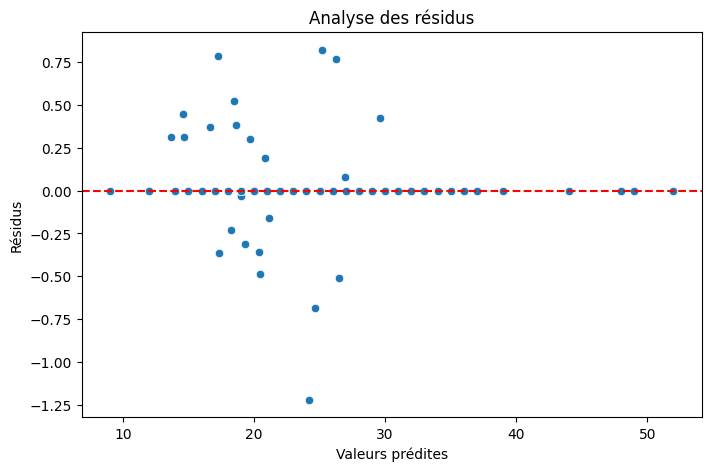

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Analyse des résidus")
plt.show()

### ➡️ Résumé

Les résultats de la régression linéaire multiple montrent que le modèle parvient à capturer une partie significative de la relation entre les caractéristiques techniques du véhicule et la consommation combinée annoncée. Avec un MAE de 0,07 et un RMSE de 0,20, les erreurs restent globalement faibles : en moyenne, le modèle se trompe d’environ 0,07 unité de consommation, ce qui est très raisonnable pour un modèle linéaire appliqué à des données automobiles hétérogènes.

L’analyse des résidus confirme cette tendance. La majorité des prédictions sont proches des valeurs réelles, plusieurs points se situent exactement sur la ligne de résidus nuls et les écarts les plus importants restent contenus entre –1,25 et +0,75, ce qui montre que le modèle ne génère pas de dérives extrêmes.

La dispersion des résidus autour de la ligne horizontale à zéro indique que le modèle ne présente pas de biais systématique : il ne surestime ni ne sous‑estime la consommation de manière uniforme. Les points au-dessus et au-dessous de la ligne se répartissent de manière relativement équilibrée, donc le modèle linéaire est bien ajusté.

En résumé, cette approche montre que les variables techniques du véhicule (cylindrée, type de transmission, score de pollution, classe du véhicule, etc.) permettent d’expliquer une part importante de la consommation annoncée. L’analyse des erreurs met en évidence quelques écarts, mais ceux‑ci restent modérés et cohérents avec la variabilité naturelle des données automobiles.